# 03 - Ingeniería de características temporales

En este cuaderno se generan características temporales a partir de la serie de consumo eléctrico para utilizarlas posteriormente en los modelos de pronóstico.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

## Carga del dataset y creación de índice temporal

In [2]:
csv_path = Path("..") / "data" / "cleaned_energy_data.csv"
df = pd.read_csv(csv_path)

date_col = [c for c in df.columns if c.lower() == "date"][0]
time_col = [c for c in df.columns if c.lower() == "time"][0]

df["datetime"] = pd.to_datetime(df[date_col] + " " + df[time_col], dayfirst=True, errors="coerce")
df = df.set_index("datetime").sort_index()

df.head()

C:\Users\frany\AppData\Local\Temp\ipykernel_26840\1999487260.py:2: DtypeWarning: Columns (0: Global_intensity, 1: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.400,0.0,1.000,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.000,0.0,1.000,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.000,0.0,2.000,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.000,0.0,1.000,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.800,0.0,1.000,17.0


## Resampling a nivel horario y selección de variable objetivo

In [8]:
df[[gap_col]]

,Global_active_power
datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666
...,...
2010-11-26 20:58:00,0.946
2010-11-26 20:59:00,0.944
2010-11-26 21:00:00,0.938


In [12]:
gap_col = [c for c in df.columns if c.lower() == "global_active_power"][0]

hourly = df.dropna()
hourly.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.400,0.0,1.000,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.000,0.0,1.000,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.000,0.0,2.000,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.000,0.0,1.000,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.800,0.0,1.000,17.0


## Creación de características de calendario

In [13]:
features = hourly.copy()
features["hour"] = features.index.hour
features["day_of_week"] = features.index.dayofweek
features["is_weekend"] = (features["day_of_week"] >= 5).astype(int)
features.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,is_weekend
datetime,,,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.400,0.0,1.000,17.0,17,5,1
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.000,0.0,1.000,16.0,17,5,1
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.000,0.0,2.000,17.0,17,5,1
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.000,0.0,1.000,17.0,17,5,1
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.800,0.0,1.000,17.0,17,5,1


## Creación de variables rezagadas y medias móviles

In [14]:
features["lag_1"] = features[gap_col].shift(1)
features["lag_24"] = features[gap_col].shift(24)
features["rolling_mean_24"] = features[gap_col].rolling(window=24, min_periods=1).mean()

features.dropna(inplace=True)
features.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,is_weekend,lag_1,lag_24,rolling_mean_24
datetime,,,,,,,,,,,,,,,
2006-12-16 17:48:00,16/12/2006,17:48:00,4.474,0.0,234.96,19.400,0.0,0.000,17.0,17,5,1,5.174,4.216,4.574917
2006-12-16 17:49:00,16/12/2006,17:49:00,3.248,0.0,236.66,13.600,0.0,0.000,17.0,17,5,1,4.474,5.360,4.486917
2006-12-16 17:50:00,16/12/2006,17:50:00,3.236,0.0,235.84,13.600,0.0,0.000,17.0,17,5,1,3.248,5.374,4.397833
2006-12-16 17:51:00,16/12/2006,17:51:00,3.228,0.0,235.60,13.600,0.0,0.000,17.0,17,5,1,3.236,5.388,4.307833
2006-12-16 17:52:00,16/12/2006,17:52:00,3.258,0.0,235.49,13.800,0.0,0.000,17.0,17,5,1,3.228,3.666,4.290833


## Visualización de patrones diarios promedio

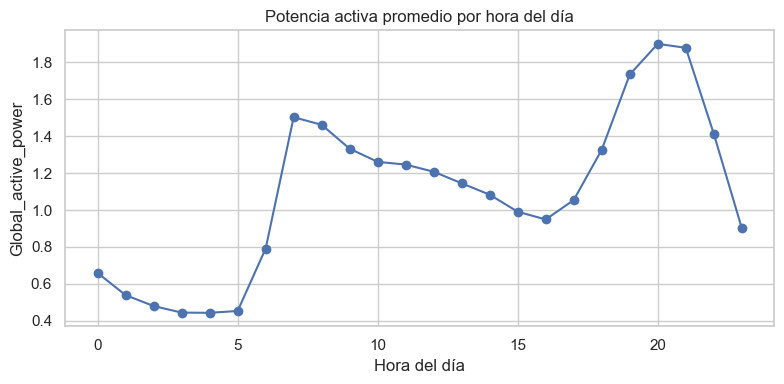

In [15]:
mean_by_hour = features.groupby("hour")[gap_col].mean()

plt.figure(figsize=(8, 4))
mean_by_hour.plot(marker="o")
plt.xlabel("Hora del día")
plt.ylabel(gap_col)
plt.title("Potencia activa promedio por hora del día")
plt.tight_layout()

## Guardado de dataset enriquecido para modelado

In [16]:
output_path = Path("..") / "data" / "household_power_consumption_features_hourly.csv"
features.to_csv(output_path)
output_path

WindowsPath('../data/household_power_consumption_features_hourly.csv')